# **Project Name**    -   Strava fitness Analysis

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** - Peritosh Sinha

# **Project Summary -**

This project analyzes user engagement and activity patterns using fitness tracking data from Strava/Fitness devices. The dataset contains information about users’ daily activities, sleep records, and weight logs. The objective of this analysis is to understand how users interact with fitness trackers and identify patterns in physical activity, sleep behavior, and health tracking.

In this project, data cleaning and preprocessing are performed using Python and the Pandas library. Exploratory Data Analysis (EDA) is conducted to examine distributions, relationships between variables, and user activity patterns. Visualizations are used to better understand trends such as step counts, calories burned, and active versus sedentary minutes.

Finally, the cleaned datasets are exported to a MySQL database where SQL queries are used to perform further analysis and generate insights about user engagement. The results help identify how frequently users track their activity, sleep, and weight, as well as how physical activity relates to other health metrics.

# **GitHub Link -**

https://github.com/Peritosh/Strava_fitness_project

# **Problem Statement**

* Fitness tracking platforms collect large amounts of data related to users’ physical activity, sleep patterns, and health metrics.

* However, understanding how users engage with these fitness tracking devices requires proper data analysis.

* The main problem is to analyze user engagement and activity patterns using fitness tracker data.

* The dataset includes information about users’ daily activity, sleep records, and weight logs.

* This project aims to examine how actively users track their health and fitness activities.

* It also analyzes whether users spend more time in active or sedentary behavior.

* The project investigates patterns such as average daily steps, calories burned, and sleep duration.

* Another objective is to explore relationships between physical activity and sleep habits.

* The insights generated from this analysis can help understand user behavior and engagement with fitness tracking platforms.

#### **Business Objective?**`

* Understand how users interact with the fitness tracking platform and measure overall user engagement.

* Analyze users’ daily activity levels using metrics such as total steps, calories burned, and active minutes.

* Identify patterns in user behavior, including how activity levels vary across different days of the week.

* Evaluate the balance between active time and sedentary time to understand user lifestyle patterns.

* Examine sleep tracking data to understand users’ sleep duration and sleep habits.

* Determine how many users actively track additional health metrics such as weight and BMI.

* Explore the relationship between physical activity and other health indicators like sleep and calories burned.

* Generate insights that can help fitness platforms improve user engagement and encourage healthier lifestyle habits.

* Provide data-driven insights that could help companies design better fitness features and personalized health recommendations.

### Import Libraries 

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import ast

In [45]:
#Dataset loading

activity = pd.read_csv(r"D:\Web_mentix_Internship\Strava_fitness_Project\Selected_Dataset\dailyActivity_merged.csv")
sleep = pd.read_csv(r"D:\Web_mentix_Internship\Strava_fitness_Project\Selected_Dataset\sleepDay_merged.csv")
weight = pd.read_csv(r"D:\Web_mentix_Internship\Strava_fitness_Project\Selected_Dataset\weightLogInfo_merged.csv")

In [46]:
#First 5 rows of activity dataset

activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [47]:
#Last 5 rows of activity dataset

activity.tail()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
935,8877689391,5/8/2016,10686,8.110000,8.110000,0.0,1.08,0.20,6.80,0.00,17,4,245,1174,2847
936,8877689391,5/9/2016,20226,18.250000,18.250000,0.0,11.10,0.80,6.24,0.05,73,19,217,1131,3710
937,8877689391,5/10/2016,10733,8.150000,8.150000,0.0,1.35,0.46,6.28,0.00,18,11,224,1187,2832
938,8877689391,5/11/2016,21420,19.559999,19.559999,0.0,13.22,0.41,5.89,0.00,88,12,213,1127,3832
939,8877689391,5/12/2016,8064,6.120000,6.120000,0.0,1.82,0.04,4.25,0.00,23,1,137,770,1849


In [48]:
#First 5 rows of sleep dataset

sleep.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [49]:
#Last 5 rows of sleep dataset

sleep.tail()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
408,8792009665,4/30/2016 12:00:00 AM,1,343,360
409,8792009665,5/1/2016 12:00:00 AM,1,503,527
410,8792009665,5/2/2016 12:00:00 AM,1,415,423
411,8792009665,5/3/2016 12:00:00 AM,1,516,545
412,8792009665,5/4/2016 12:00:00 AM,1,439,463


In [50]:
#First 5 rows of weight dataset

weight.head()

,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,5/2/2016 11:59:59 PM,52.599998,115.963147,22.0,22.650000,True,1462233599000
1,1503960366,5/3/2016 11:59:59 PM,52.599998,115.963147,NaN,22.650000,True,1462319999000
2,1927972279,4/13/2016 1:08:52 AM,133.500000,294.317120,NaN,47.540001,False,1460509732000
3,2873212765,4/21/2016 11:59:59 PM,56.700001,125.002104,NaN,21.450001,True,1461283199000
4,2873212765,5/12/2016 11:59:59 PM,57.299999,126.324875,NaN,21.690001,True,1463097599000


In [51]:
#Last 5 rows of weight dataset

weight.tail()

,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
62,8877689391,5/6/2016 6:43:35 AM,85.000000,187.392923,NaN,25.440001,False,1462517015000
63,8877689391,5/8/2016 7:35:53 AM,85.400002,188.274775,NaN,25.559999,False,1462692953000
64,8877689391,5/9/2016 6:39:44 AM,85.500000,188.495234,NaN,25.610001,False,1462775984000
65,8877689391,5/11/2016 6:51:47 AM,85.400002,188.274775,NaN,25.559999,False,1462949507000
66,8877689391,5/12/2016 6:42:53 AM,84.000000,185.188300,NaN,25.139999,False,1463035373000


In [52]:
#Getting the info of activity dataset
activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

In [54]:
#Getting the info of sleep dataset
sleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  413 non-null    int64 
 1   SleepDay            413 non-null    object
 2   TotalSleepRecords   413 non-null    int64 
 3   TotalMinutesAsleep  413 non-null    int64 
 4   TotalTimeInBed      413 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 16.3+ KB


In [56]:
#Getting the info of weight dataset
weight.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              67 non-null     int64  
 1   Date            67 non-null     object 
 2   WeightKg        67 non-null     float64
 3   WeightPounds    67 non-null     float64
 4   Fat             2 non-null      float64
 5   BMI             67 non-null     float64
 6   IsManualReport  67 non-null     bool   
 7   LogId           67 non-null     int64  
dtypes: bool(1), float64(4), int64(2), object(1)
memory usage: 3.9+ KB


In [57]:
#Droping the Fat column from weight dataset becuase it contained 65 missing values out of 67 records.
weight = weight.drop(columns=['Fat'])

In [58]:
weight.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              67 non-null     int64  
 1   Date            67 non-null     object 
 2   WeightKg        67 non-null     float64
 3   WeightPounds    67 non-null     float64
 4   BMI             67 non-null     float64
 5   IsManualReport  67 non-null     bool   
 6   LogId           67 non-null     int64  
dtypes: bool(1), float64(3), int64(2), object(1)
memory usage: 3.3+ KB


In [60]:
activity['ActivityDate'] = pd.to_datetime(activity['ActivityDate'], format='%m/%d/%Y')
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')
weight['Date'] = pd.to_datetime(weight['Date'], format='%m/%d/%Y %I:%M:%S %p')

In [61]:
print(activity.info())
print(sleep.info())
print(weight.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes  

In [62]:
#Creating the new columns for better understanding in activity dataset
activity['DayOfWeek'] = activity['ActivityDate'].dt.day_name()
activity['Month'] = activity['ActivityDate'].dt.month

In [63]:
activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes  

In [65]:
#Checking the unique values in the id columns of activity, sleep and weight datasets

print(activity['Id'].nunique())
print(sleep['Id'].nunique())
print(weight['Id'].nunique())

33
24
8


In [66]:
activity.describe()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Month
count,9.400000e+02,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,2016-04-26 06:53:37.021276672,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574,4.350000
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,2.320127e+09,2016-04-19 00:00:00,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000,4.000000
50%,4.445115e+09,2016-04-26 00:00:00,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000,4.000000
75%,6.962181e+09,2016-05-04 00:00:00,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000,5.000000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000,5.000000
std,2.424805e+09,NaN,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862,0.477224


In [67]:
sleep.describe()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,4.130000e+02,413,413.000000,413.000000,413.000000
mean,5.000979e+09,2016-04-26 12:40:05.811137792,1.118644,419.467312,458.639225
min,1.503960e+09,2016-04-12 00:00:00,1.000000,58.000000,61.000000
25%,3.977334e+09,2016-04-19 00:00:00,1.000000,361.000000,403.000000
50%,4.702922e+09,2016-04-27 00:00:00,1.000000,433.000000,463.000000
75%,6.962181e+09,2016-05-04 00:00:00,1.000000,490.000000,526.000000
max,8.792010e+09,2016-05-12 00:00:00,3.000000,796.000000,961.000000
std,2.060360e+09,NaN,0.345521,118.344679,127.101607


## **Visualizations** 

### Chart 01

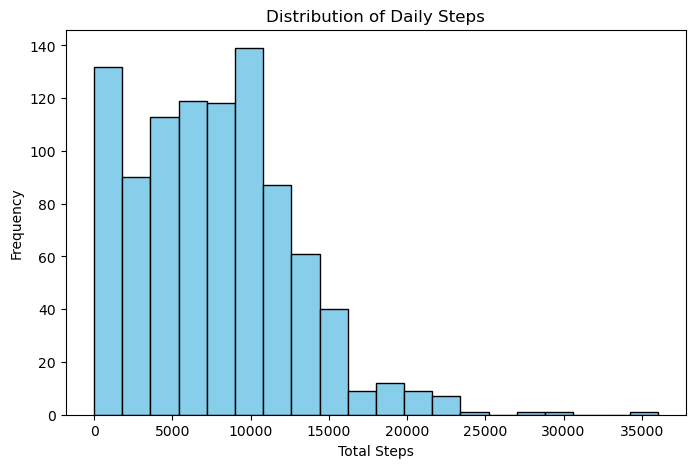

In [69]:
#Distribution of Daily Steps

plt.figure(figsize=(8,5))
plt.hist(activity['TotalSteps'], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Daily Steps")
plt.xlabel("Total Steps")
plt.ylabel("Frequency")
plt.show()

### Chart 02

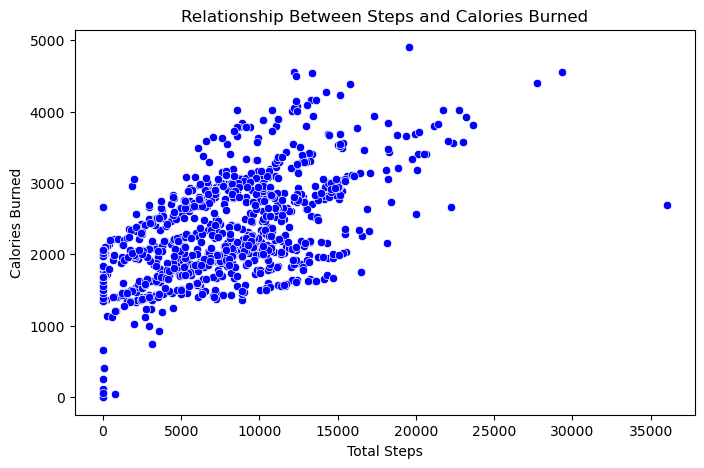

In [72]:
#Steps vs Calories

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='TotalSteps',
    y='Calories',
    data=activity,
    color='blue'
)
plt.title("Relationship Between Steps and Calories Burned")
plt.xlabel("Total Steps")
plt.ylabel("Calories Burned")
plt.show()

### Chart 03

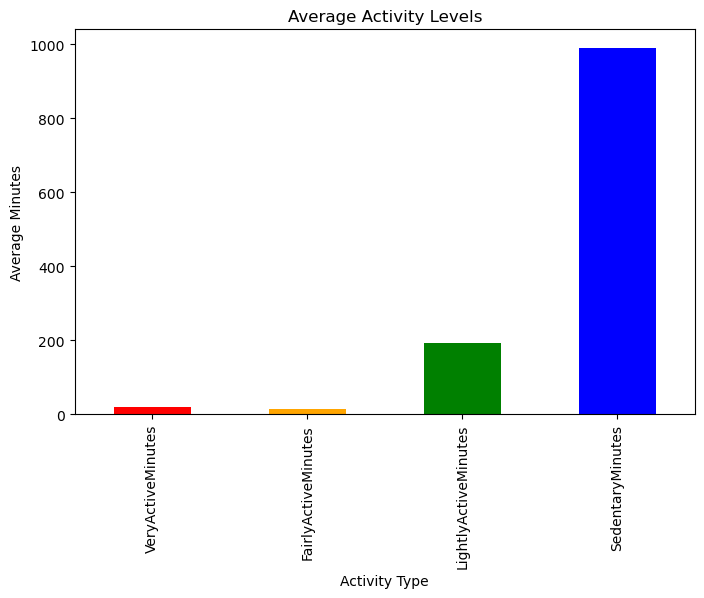

In [73]:
#Activity Level Comparison

activity_levels = activity[['VeryActiveMinutes',
                            'FairlyActiveMinutes',
                            'LightlyActiveMinutes',
                            'SedentaryMinutes']].mean()
plt.figure(figsize=(8,5))
activity_levels.plot(kind='bar', color=['red','orange','green','blue'])
plt.title("Average Activity Levels")
plt.xlabel("Activity Type")
plt.ylabel("Average Minutes")
plt.show()

### Chart 04

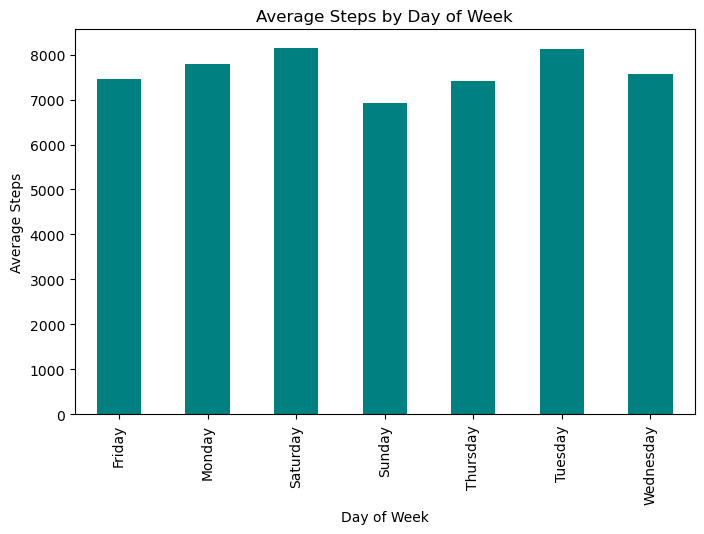

In [74]:
#Average Steps by Day of Week

steps_by_day = activity.groupby('DayOfWeek')['TotalSteps'].mean()
plt.figure(figsize=(8,5))
steps_by_day.plot(kind='bar', color='teal')
plt.title("Average Steps by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Steps")
plt.show()

### Chart 05

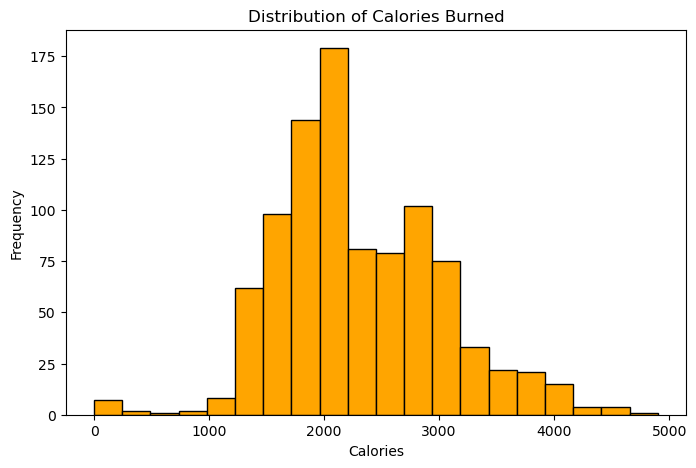

In [75]:
#Calories Distribution

plt.figure(figsize=(8,5))
plt.hist(activity['Calories'], bins=20, color='orange', edgecolor='black')
plt.title("Distribution of Calories Burned")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

### Chart 06

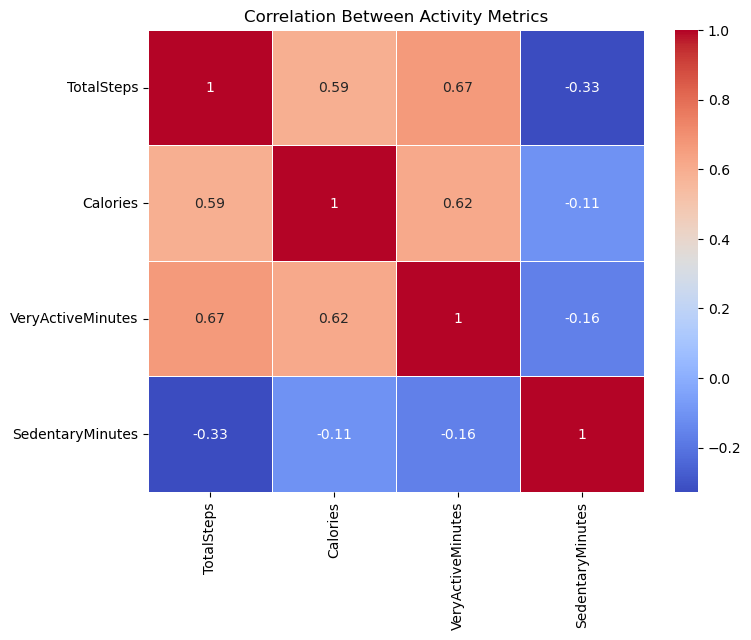

In [76]:
#Correlation Heatmap

plt.figure(figsize=(8,6))
corr_matrix = activity[['TotalSteps',
                        'Calories',
                        'VeryActiveMinutes',
                        'SedentaryMinutes']].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Between Activity Metrics")
plt.show()

In [77]:
#Merged activity and sleep dataset

merged = pd.merge(activity, sleep, on='Id')

### Chart 07

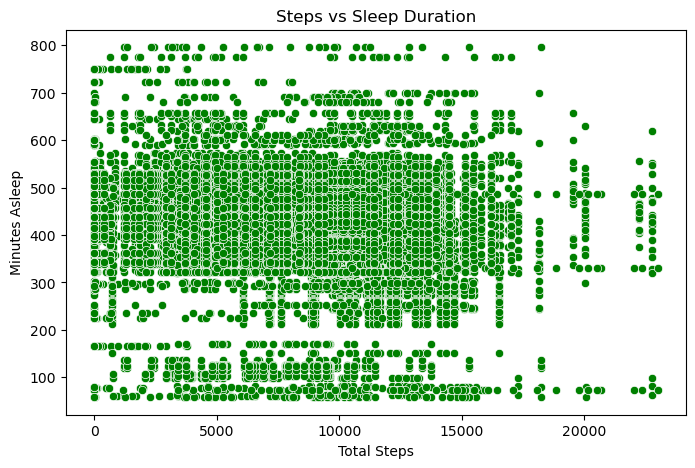

In [78]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='TotalSteps',
    y='TotalMinutesAsleep',
    data=merged,
    color='green'
)
plt.title("Steps vs Sleep Duration")
plt.xlabel("Total Steps")
plt.ylabel("Minutes Asleep")
plt.show()

## **Exporting the datasets into mysql**

In [80]:
username = "root"
password = "Peri13"
host = "localhost"
port = "3306"
database = "strava_fitness"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

In [82]:
activity.to_sql(
    name="dailyactivity",
    con=engine,
    if_exists="replace",
    index=False
)

940

In [83]:
sleep.to_sql(
    name="sleepday",
    con=engine,
    if_exists="replace",
    index=False
)

413

In [84]:
weight.to_sql(
    name="weightloginfo",
    con=engine,
    if_exists="replace",
    index=False
)

67